# Hierarchical Bayesian fitting: a synthetic parameter-recovery walkthrough

`aind_dynamic_foraging_models.hierarchical_bayes` fits the foragers as **hierarchical
Bayesian** models with NumPyro, as a partially-pooled counterpart to the per-session MLE
fitting in `generative_model`. The hierarchy has three levels:

```
population   ->   subject   ->   session   ->   trials
 (cohort)        (mouse)      (one day's data)
```

A session's parameters are drawn from its subject's distribution, and each subject's
distribution is drawn from the cohort's. So a session with few trials borrows strength
from the rest of that mouse, and a mouse with few sessions borrows strength from the rest
of the cohort. That borrowing is the whole point, and this notebook measures it.

**Why synthetic data first.** On real data you never learn whether a fit is right, only
whether it converged. Here we *simulate* a cohort from the same generative structure the
model assumes, so the true population, subject and session parameters are known, and every
estimate can be scored against them. This is the standard first check on any fitting
pipeline: if it cannot recover parameters it generated itself, nothing it says about real
mice is worth reading.

**What we will do**

1. Simulate a toy cohort with known ground truth
2. Check the JAX likelihood is the same model as the numpy forager
3. Fit **one subject** with the two-level model, and read its diagnostics
4. Fit the **whole cohort**, both ways the package offers — two-stage and one-stage
5. Look at what pooling actually bought: **shrinkage**, and error against truth
6. Take a **new subject the fit never saw** and ask how many of its own sessions it takes
   before its data beats the cohort prior
7. Save the fit so the expensive part never has to be repeated

**Requirements.** The `bayes` extra (JAX, NumPyro, ArviZ, xarray):

```bash
pip install -e ".[bayes,rl]"
```

**Runtime.** Everything below is deliberately toy-sized — 16 subjects, at most 8 sessions
each, 300 trials per session — and runs in roughly 10-15 minutes on a laptop CPU. Real
cohort fits are far larger and belong on a GPU; see
[`benchmarks/RESULTS.md`](../src/aind_dynamic_foraging_models/hierarchical_bayes/benchmarks/RESULTS.md)
for measured timings.

In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")  # NumPyro/JAX chatter; drop this line when debugging

import json
import tempfile
import time

import arviz as az
import jax
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

from aind_behavior_gym.dynamic_foraging.task import CoupledBlockTask

from aind_dynamic_foraging_models.generative_model import ForagerCollection
from aind_dynamic_foraging_models.hierarchical_bayes import hattori2019_choice_prob, plotting
from aind_dynamic_foraging_models.hierarchical_bayes.model import (
    HATTORI2019_PARAMS,
    hattori2019_session_params,
    hattori2019_three_level,
)

print("jax", jax.__version__, "on", jax.devices()[0])
print("parameters:", HATTORI2019_PARAMS)

jax 0.11.1 on cpu:0
parameters: ('learn_rate_rew', 'learn_rate_unrew', 'forget_rate_unchosen', 'softmax_inverse_temperature', 'bias_l')


## 1. The parameterisation

Every parameter is sampled on an **unconstrained** scale and pushed through the standard
normal CDF $\Phi$ into its bounded range:

$$\alpha_{+},\ \alpha_{-},\ \delta = \Phi(\theta) \in (0,1), \qquad
\beta = \Phi(\theta)\cdot\beta_{\max} \in (0,\beta_{\max}), \qquad
b_L = \theta \in \mathbb{R}$$

Two things follow, and both matter. The sampler only ever sees an unbounded space, so NUTS
never has to deal with a boundary; and a standard normal on that scale is *exactly* a
uniform prior on the bounded one, which is how the published model expresses its
"non-informative" priors. Every number in this notebook that says `mu_p`, `sigma`,
`population_mean` or `theta` lives on the unconstrained scale;
`plotting.to_bounded` maps back for the figures.

In [2]:
BETA_MAX = 10.0

demo = np.array([-1.0, 0.0, 1.0])
print(f"{'unconstrained':>14} {'-> Phi(x)':>12} {'-> beta':>10}")
for x in demo:
    print(f"{x:>14.1f} {float(norm.cdf(x)):>12.3f} {float(norm.cdf(x) * BETA_MAX):>10.3f}")

# The model's own mapping, applied to a whole parameter vector at once:
hattori2019_session_params(np.zeros(5), beta_max=BETA_MAX)

 unconstrained    -> Phi(x)    -> beta
          -1.0        0.159      1.587
           0.0        0.500      5.000
           1.0        0.841      8.413


{'learn_rate_rew': Array(0.5, dtype=float32),
 'learn_rate_unrew': Array(0.5, dtype=float32),
 'forget_rate_unchosen': Array(0.5, dtype=float32),
 'softmax_inverse_temperature': Array(5., dtype=float32),
 'bias_l': array(0.)}

## 2. Simulate a cohort with known ground truth

We draw straight down the generative hierarchy: a population location and spread give each
subject a `mu_p`, each subject's `mu_p` and `sigma` give each session a parameter vector,
and that session's forager then plays a coupled-block foraging task with reward baiting.

Two deliberate choices in this toy cohort:

- **Subjects have unequal numbers of sessions** (between 2 and 8). Shrinkage is a
  data-dependent effect — a subject with 2 sessions should be pulled toward the cohort much
  harder than one with 8 — and a balanced cohort would hide it.
- **Four subjects are held out entirely.** They never enter any fit, and in section 6 they
  become the new mice we have to predict.

In [3]:
N_PARAMS = len(HATTORI2019_PARAMS)

# --- ground truth, on the unconstrained scale --------------------------------------
TRUE_POPULATION_MEAN = np.array([0.3, -0.6, -0.8, 0.2, 0.0])  # where the cohort sits
TRUE_POPULATION_SCALE = np.array([0.4, 0.4, 0.4, 0.4, 0.3])   # spread across subjects
TRUE_SESSION_SIGMA = np.array([0.25] * N_PARAMS)              # spread across sessions

N_TRAIN, N_HELDOUT = 12, 4
MAX_SESSIONS, N_TRIALS = 8, 300
SEED = 42

print("the cohort we are trying to recover, in the forager's own units:")
for name, value in hattori2019_session_params(TRUE_POPULATION_MEAN, beta_max=BETA_MAX).items():
    print(f"  {name:>28}  {float(value):.3f}")

the cohort we are trying to recover, in the forager's own units:
                learn_rate_rew  0.618
              learn_rate_unrew  0.274
          forget_rate_unchosen  0.212
   softmax_inverse_temperature  5.793
                        bias_l  0.000


In [4]:
def simulate_session(theta, seed):
    """Play one session with a forager whose parameters are the unconstrained vector theta."""
    bounded = hattori2019_session_params(np.asarray(theta), beta_max=BETA_MAX)
    forager = ForagerCollection().get_preset_forager("Hattori2019", seed=seed)
    forager.set_params(
        learn_rate_rew=float(bounded["learn_rate_rew"]),
        learn_rate_unrew=float(bounded["learn_rate_unrew"]),
        forget_rate_unchosen=float(bounded["forget_rate_unchosen"]),
        softmax_inverse_temperature=float(bounded["softmax_inverse_temperature"]),
        biasL=float(bounded["bias_l"]),
    )
    forager.perform(CoupledBlockTask(reward_baiting=True, num_trials=N_TRIALS, seed=seed))
    return forager.get_choice_history(), forager.get_reward_history()


rng = np.random.default_rng(SEED)
n_subjects = N_TRAIN + N_HELDOUT

# Population -> subjects
true_mu_p = TRUE_POPULATION_MEAN + TRUE_POPULATION_SCALE * rng.standard_normal(
    (n_subjects, N_PARAMS)
)

# Unequal session counts for the training subjects; the held-out ones get a full set,
# because section 6 needs context sessions *and* disjoint test sessions from each.
n_sessions = np.concatenate(
    [rng.integers(2, MAX_SESSIONS + 1, N_TRAIN), np.full(N_HELDOUT, MAX_SESSIONS)]
)

# Subjects -> sessions -> trials. Ragged session counts are padded to MAX_SESSIONS and
# excluded with session_mask, which is exactly how real cohorts enter the model.
choices = np.zeros((n_subjects, MAX_SESSIONS, N_TRIALS), dtype=int)
rewards = np.zeros((n_subjects, MAX_SESSIONS, N_TRIALS), dtype=float)
session_mask = np.zeros((n_subjects, MAX_SESSIONS), dtype=bool)
true_theta = np.full((n_subjects, MAX_SESSIONS, N_PARAMS), np.nan)

for subject in range(n_subjects):
    for session in range(n_sessions[subject]):
        true_theta[subject, session] = true_mu_p[subject] + TRUE_SESSION_SIGMA * (
            rng.standard_normal(N_PARAMS)
        )
        choices[subject, session], rewards[subject, session] = simulate_session(
            true_theta[subject, session], seed=subject * 100 + session
        )
        session_mask[subject, session] = True

print(f"{n_subjects} subjects ({N_TRAIN} train + {N_HELDOUT} held out), "
      f"{int(session_mask.sum())} sessions, {N_TRIALS} trials each")
print("sessions per training subject:", n_sessions[:N_TRAIN])
print(f"overall reward rate: {rewards[session_mask].mean():.3f}")

16 subjects (12 train + 4 held out), 85 sessions, 300 trials each
sessions per training subject: [4 7 4 3 4 2 2 2 7 7 6 5]
overall reward rate: 0.347


## 3. Sanity check: is the JAX likelihood the same model?

`hierarchical_bayes.likelihood` is an *independent* reimplementation of the trial dynamics
in `generative_model` — it deliberately shares no code, so that agreement between the two is
real evidence rather than a tautology. Before trusting any posterior, confirm the two agree
on the same session.

The comparison is against a **teacher-forced** replay (`perform_closed_loop`): the
likelihood asks what probability the agent assigned to the choices that were actually made,
not what it would have done left to itself.

In [5]:
theta = true_theta[0, 0]
bounded = hattori2019_session_params(theta, beta_max=BETA_MAX)

forager = ForagerCollection().get_preset_forager("Hattori2019", seed=0)
forager.set_params(
    learn_rate_rew=float(bounded["learn_rate_rew"]),
    learn_rate_unrew=float(bounded["learn_rate_unrew"]),
    forget_rate_unchosen=float(bounded["forget_rate_unchosen"]),
    softmax_inverse_temperature=float(bounded["softmax_inverse_temperature"]),
    biasL=float(bounded["bias_l"]),
)
forager.perform_closed_loop(choices[0, 0], rewards[0, 0])

jax_prob = np.asarray(
    hattori2019_choice_prob(
        choices[0, 0], rewards[0, 0],
        learn_rate_rew=bounded["learn_rate_rew"],
        learn_rate_unrew=bounded["learn_rate_unrew"],
        forget_rate_unchosen=bounded["forget_rate_unchosen"],
        softmax_inverse_temperature=bounded["softmax_inverse_temperature"],
        bias_l=bounded["bias_l"],
    )
)

print(f"max |JAX - numpy| over {jax_prob.size} choice probabilities: "
      f"{np.abs(jax_prob - forager.choice_prob).max():.2e}")

max |JAX - numpy| over 600 choice probabilities: 1.35e-07


## 4. Fit one subject: the two-level model

`hattori2019_two_level` is the unit the rest is built from — one subject's sessions, with
subject-level hyperparameters `mu_p` (where that mouse sits) and `sigma` (how much it varies
session to session) above them.

The session parameters are **non-centred** by default (`theta = mu_p + sigma * theta_raw`
with `theta_raw ~ Normal(0, 1)`). Sampling `theta` directly from `Normal(mu_p, sigma)`
produces the classic funnel geometry when a session's data are weak, and NUTS handles it
badly. That was verified rather than assumed: a sweep over centred/non-centred, diagonal and
dense mass matrices and target acceptance found the non-centred form best on every measure,
with the centred one producing divergences. Pass `centered=True` to see it, and
`benchmarks/geometry_experiment.py` is the script that re-runs the check on new data.

We ask for two chains so that `r_hat` means something.

In [6]:
from aind_dynamic_foraging_models.hierarchical_bayes.two_stage import fit_subject

SUBJECT = 0
k = n_sessions[SUBJECT]

started = time.time()
subject_mcmc = fit_subject(
    choices[SUBJECT, :k],
    rewards[SUBJECT, :k],
    rng_key=jax.random.PRNGKey(0),
    num_warmup=500,
    num_samples=500,
    num_chains=2,
)
print(f"subject {SUBJECT}: {k} sessions fitted in {time.time() - started:.0f}s")

subject_idata = az.from_numpyro(subject_mcmc)
az.summary(subject_idata, var_names=["mu_p", "sigma"]).round(3)

subject 0: 4 sessions fitted in 37s


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_p[0],0.15,0.37,-0.37,0.76,578,527,1.00,0.015,0.012
mu_p[1],-1.1,0.14,-1.3,-0.88,478,552,1.00,0.0068,0.0071
mu_p[2],-0.33,0.38,-0.85,0.27,684,633,1.00,0.016,0.019
mu_p[3],0.78,0.51,0.18,1.7,601,532,1.00,0.024,0.024
mu_p[4],-0.62,0.27,-0.99,-0.16,703,456,1.00,0.011,0.0098
sigma[0],0.31,0.26,0.062,0.72,715,632,1.00,0.011,0.02
sigma[1],0.18,0.13,0.049,0.42,541,582,1.01,0.006,0.013
sigma[2],0.35,0.3,0.063,0.83,948,643,1.00,0.011,0.021
sigma[3],0.35,0.31,0.064,0.9,935,671,1.00,0.012,0.019
sigma[4],0.37,0.26,0.081,0.82,487,582,1.00,0.011,0.017


**Reading the table.** `r_hat` should sit at 1.00 (above ~1.01 means the chains have not
mixed), and `ess_bulk` in the hundreds means there are enough effectively-independent draws
to trust the posterior mean. Also check the divergence count below: divergences are NUTS
reporting that it could not follow the geometry, and a fit with many of them is not a fit.

In [7]:
divergences = int(np.sum(np.asarray(subject_mcmc.get_extra_fields()["diverging"])))
print(f"divergences: {divergences} / {subject_mcmc.num_samples * subject_mcmc.num_chains} draws")

# Did we recover this subject's own location?
posterior_mu_p = np.asarray(subject_mcmc.get_samples()["mu_p"])
print(f"\n{'parameter':>28} {'truth':>8} {'posterior mean':>16} {'89% interval':>22}")
for i, name in enumerate(HATTORI2019_PARAMS):
    draws = posterior_mu_p[:, i]
    lo, hi = np.percentile(draws, [5.5, 94.5])
    print(f"{name:>28} {true_mu_p[SUBJECT, i]:>8.2f} {draws.mean():>16.2f}"
          f"   [{lo:>6.2f}, {hi:>6.2f}]")

divergences: 0 / 1000 draws

                   parameter    truth   posterior mean           89% interval
              learn_rate_rew     0.42             0.15   [ -0.37,   0.76]
            learn_rate_unrew    -1.02            -1.10   [ -1.33,  -0.88]
        forget_rate_unchosen    -0.50            -0.33   [ -0.85,   0.27]
 softmax_inverse_temperature     0.58             0.78   [  0.18,   1.73]
                      bias_l    -0.59            -0.62   [ -0.99,  -0.16]


Now the session level. Each of this subject's sessions has its own parameter vector, and the
model estimates all of them jointly with the subject-level distribution they came from. With
only 300 trials per session these are genuinely uncertain — which is the point of pooling
them rather than fitting each session alone.

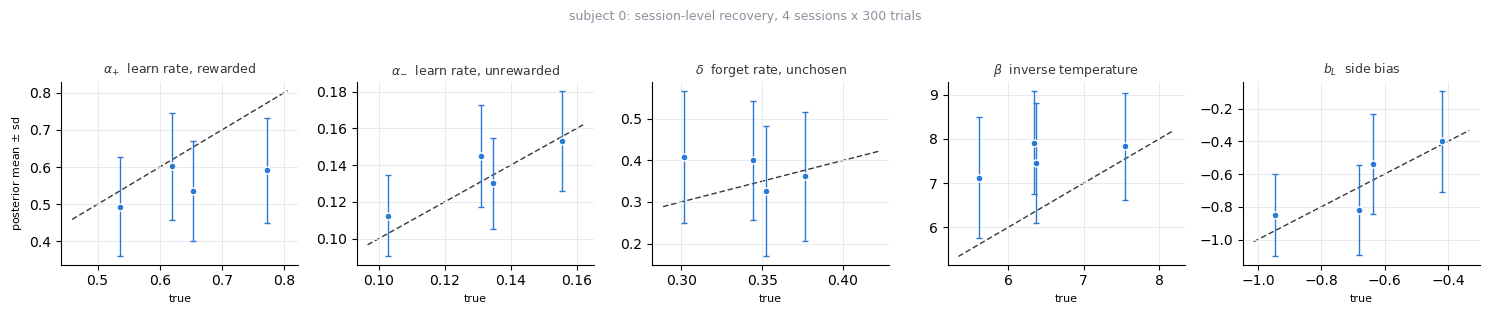

In [8]:
session_draws = {name: np.asarray(subject_mcmc.get_samples()[name]) for name in HATTORI2019_PARAMS}

fig, axes = plt.subplots(1, N_PARAMS, figsize=(3.0 * N_PARAMS, 3.0))
for i, (name, ax) in enumerate(zip(HATTORI2019_PARAMS, axes)):
    truth = plotting.to_bounded(true_theta[SUBJECT, :k, i], i, BETA_MAX)
    estimate = session_draws[name].mean(axis=0)
    spread = session_draws[name].std(axis=0)
    ax.errorbar(truth, estimate, yerr=spread, fmt="o", color=plotting.HB,
                markersize=5, markeredgecolor="white", capsize=2, linewidth=1)
    lo = min(truth.min(), estimate.min())
    hi = max(truth.max(), estimate.max())
    pad = 0.12 * (hi - lo + 1e-6)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], color=plotting.INK,
            linewidth=1, linestyle=(0, (4, 2)), zorder=0)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.grid(True, color=plotting.GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    ax.set_title(plotting.PARAM_LABELS[name], fontsize=9, color=plotting.INK)
    ax.set_xlabel("true", fontsize=8)
    if i == 0:
        ax.set_ylabel("posterior mean $\\pm$ sd", fontsize=8)
fig.suptitle(f"subject {SUBJECT}: session-level recovery, {k} sessions x {N_TRIALS} trials",
             fontsize=9, color=plotting.MUTED, y=1.03)
fig.tight_layout()
plt.close(fig)   # this one is drawn under the inline backend; close it so it shows once
fig

## 5. Fit the cohort

The package offers two estimators for the third level, and they are not the same thing.

**Two-stage empirical Bayes** (`two_stage.fit_two_stage`) fits every subject
independently, then fits a population distribution to the resulting subject posteriors. Its
population stage consumes each subject's posterior **mean and standard error**, not the mean
alone — fitting to point estimates would count each subject's own posterior uncertainty as
between-subject variance and inflate the population scale.

Its individual fits are small and independent, which is why it was built as the cheap,
scalable option. Measurement reversed that: because wall time here is set by the sequential
scan over trials, a joint fit pays that depth *once for the whole cohort* while sequential
per-subject fitting pays it once per subject. On a real cohort the batched one-stage fit
finished in 3 h 32 m while two-stage on the same data was still running past 5 h 45 m. So
two-stage has to justify itself on statistics, not speed.

**One-stage joint** (`model.hattori2019_three_level`) infers everything at once.
Information then flows in both directions: a subject with few sessions is pulled toward the
cohort, and that shrinkage reaches its session parameters too. Two-stage cannot do the
latter, because its subject fits are finished before the population exists.

We run both, and use the two-stage subject fits as the **unpooled** reference in section 6 —
they are, by construction, each subject fitted with no knowledge of the cohort.

In [9]:
from aind_dynamic_foraging_models.hierarchical_bayes.two_stage import fit_two_stage

started = time.time()
two_stage = fit_two_stage(
    [(choices[i, :n_sessions[i]], rewards[i, :n_sessions[i]]) for i in range(N_TRAIN)],
    rng_key=jax.random.PRNGKey(1),
    subject_kwargs=dict(num_warmup=500, num_samples=500),
    population_kwargs=dict(num_warmup=500, num_samples=500),
)
print(f"two-stage over {N_TRAIN} subjects: {time.time() - started:.0f}s")

# subject_estimates stacks [mu_p, log_sigma], so the first N_PARAMS columns are the
# locations. These are the *unpooled* subject estimates.
unpooled_mu_p = two_stage["subject_estimates"][:, :N_PARAMS]

two_stage_population = np.asarray(
    two_stage["population_mcmc"].get_samples()["population_mean"]
).mean(axis=0)[:N_PARAMS]
print("two-stage population mean:", two_stage_population.round(2))
print("             ground truth:", TRUE_POPULATION_MEAN)

two-stage over 12 subjects: 249s


two-stage population mean: [ 0.21 -0.51 -0.6   0.09 -0.02]
             ground truth: [ 0.3 -0.6 -0.8  0.2  0. ]


In [10]:
from numpyro.infer import MCMC, NUTS

started = time.time()
joint_mcmc = MCMC(
    NUTS(hattori2019_three_level),
    num_warmup=500,
    num_samples=500,
    num_chains=2,
    chain_method="vectorized",   # one CPU device: run the chains as a batch axis
    progress_bar=False,
)
joint_mcmc.run(
    jax.random.PRNGKey(2),
    choices[:N_TRAIN],
    rewards[:N_TRAIN],
    session_mask=session_mask[:N_TRAIN],   # excludes the padded session slots
)
print(f"one-stage joint fit: {time.time() - started:.0f}s")

joint_samples = joint_mcmc.get_samples()
joint_idata = az.from_numpyro(joint_mcmc)
print("divergences:",
      int(np.sum(np.asarray(joint_mcmc.get_extra_fields()["diverging"]))))
az.summary(joint_idata, var_names=["population_mean", "population_scale"]).round(3)

one-stage joint fit: 6s


divergences: 7


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
population_mean[0],0.41,0.14,0.22,0.64,391,426,1.01,0.0068,0.0062
population_mean[1],-0.55,0.1,-0.71,-0.4,301,374,1.02,0.0059,0.0052
population_mean[2],-0.7,0.17,-0.97,-0.44,351,296,1.03,0.0089,0.0071
population_mean[3],0.181,0.094,0.041,0.34,572,585,1.00,0.0039,0.0034
population_mean[4],0.01,0.11,-0.15,0.2,272,455,1.01,0.0065,0.0054
population_scale[0],0.25,0.16,0.018,0.54,131,77,1.01,0.012,0.0092
population_scale[1],0.33,0.09,0.22,0.5,188,326,1.03,0.006,0.006
population_scale[2],0.51,0.16,0.29,0.8,254,344,1.00,0.01,0.0095
population_scale[3],0.21,0.11,0.041,0.41,200,150,1.00,0.0075,0.007
population_scale[4],0.35,0.11,0.21,0.56,245,418,1.00,0.0067,0.0061


### Did we recover the population?

`plot_population_recovery` draws the population posterior for each parameter in the
forager's own units, with every subject's estimate as a tick beneath it and the generating
value as a dashed line. The population posterior should cover the truth; the ticks show the
between-subject spread the population level is summarising.

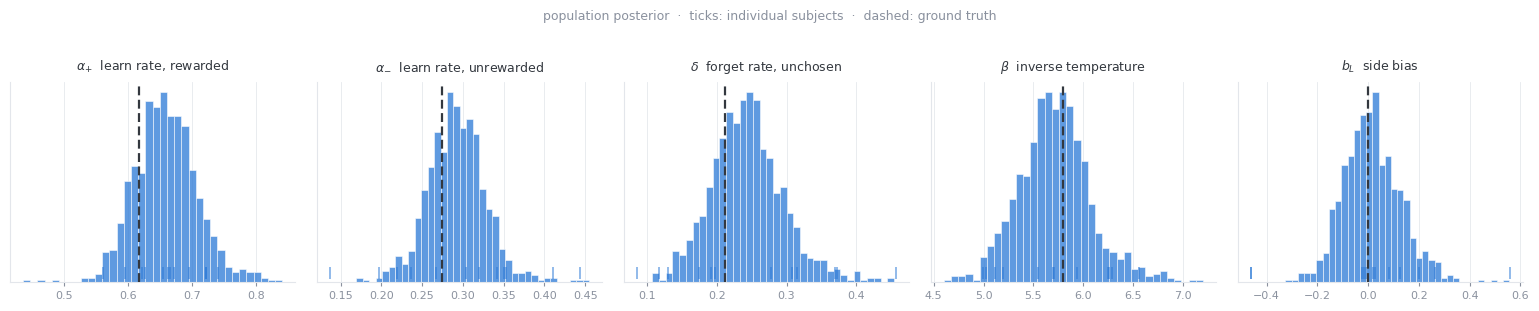

In [11]:
fig = plotting.plot_population_recovery(
    np.asarray(joint_samples["population_mean"]),
    np.asarray(joint_samples["mu_p"]).mean(axis=0),
    truth=TRUE_POPULATION_MEAN,
    param_names=list(HATTORI2019_PARAMS),
    beta_max=BETA_MAX,
)
fig

In [12]:
print(f"{'parameter':>28} {'truth':>8} {'one-stage':>11} {'two-stage':>11}")
joint_population = np.asarray(joint_samples["population_mean"]).mean(axis=0)
for i, name in enumerate(HATTORI2019_PARAMS):
    print(f"{name:>28} {TRUE_POPULATION_MEAN[i]:>8.2f} "
          f"{joint_population[i]:>11.2f} {two_stage_population[i]:>11.2f}")

                   parameter    truth   one-stage   two-stage
              learn_rate_rew     0.30        0.41        0.21
            learn_rate_unrew    -0.60       -0.55       -0.51
        forget_rate_unchosen    -0.80       -0.70       -0.60
 softmax_inverse_temperature     0.20        0.18        0.09
                      bias_l     0.00        0.01       -0.02


## 6. What pooling bought: shrinkage

This is the argument for the hierarchy, and on synthetic data we can check it rather than
assert it. Each subject has two estimates of the same quantity:

- **unpooled** — that subject fitted alone, knowing nothing about the cohort
- **partially pooled** — the same subject's `mu_p` out of the joint fit

Pooling pulls each subject toward the cohort, and it should pull hardest on the subjects
with the least data. Since we know the truth, we can also ask the question that matters: does
that pull move subjects *closer to* their true values, or merely closer together?

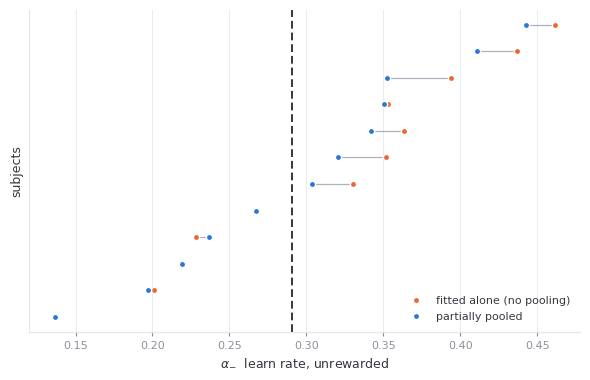

In [13]:
pooled_mu_p = np.asarray(joint_samples["mu_p"]).mean(axis=0)

fig = plotting.plot_shrinkage(
    pooled_mu_p,
    joint_population,
    unpooled=unpooled_mu_p,
    param_index=1,   # learn_rate_unrew
    beta_max=BETA_MAX,
)
fig

In [14]:
truth = true_mu_p[:N_TRAIN]
error_unpooled = np.abs(unpooled_mu_p - truth)
error_pooled = np.abs(pooled_mu_p - truth)

print("mean absolute error against the true subject locations (unconstrained scale)")
print(f"{'parameter':>28} {'unpooled':>10} {'pooled':>10} {'change':>10}")
for i, name in enumerate(HATTORI2019_PARAMS):
    a, b = error_unpooled[:, i].mean(), error_pooled[:, i].mean()
    print(f"{name:>28} {a:>10.3f} {b:>10.3f} {b - a:>+10.3f}")
print(f"{'ALL':>28} {error_unpooled.mean():>10.3f} {error_pooled.mean():>10.3f} "
      f"{error_pooled.mean() - error_unpooled.mean():>+10.3f}")

# Pooling should help most where the data are thinnest.
few = n_sessions[:N_TRAIN] <= 3
print(f"\nsubjects with <= 3 sessions (n={int(few.sum())}): "
      f"unpooled {error_unpooled[few].mean():.3f} -> pooled {error_pooled[few].mean():.3f}")
print(f"subjects with  > 3 sessions (n={int((~few).sum())}): "
      f"unpooled {error_unpooled[~few].mean():.3f} -> pooled {error_pooled[~few].mean():.3f}")

mean absolute error against the true subject locations (unconstrained scale)
                   parameter   unpooled     pooled     change
              learn_rate_rew      0.168      0.213     +0.044
            learn_rate_unrew      0.102      0.087     -0.015
        forget_rate_unchosen      0.274      0.141     -0.133
 softmax_inverse_temperature      0.191      0.184     -0.007
                      bias_l      0.146      0.124     -0.022
                         ALL      0.176      0.150     -0.027

subjects with <= 3 sessions (n=4): unpooled 0.225 -> pooled 0.214
subjects with  > 3 sessions (n=8): unpooled 0.152 -> pooled 0.117


**What actually came out, which is not quite the textbook story.**

Pooling lowered the mean absolute error overall, and on four of the five parameters. The
biggest gain by far is on `forget_rate_unchosen` — the parameter a single session constrains
worst, and therefore the one with the most to borrow. It made `learn_rate_rew` slightly
*worse*. That is the honest shape of shrinkage rather than a failure: it trades variance for
bias, so a subject that genuinely sits away from the cohort gets pulled the wrong way, and
you buy that with a larger gain elsewhere.

The split by session count came out backwards from the usual claim — the subjects with the
fewest sessions improved least. Do not read anything into that. With 12 training subjects,
four of them in the small group, one simulated cohort and one seed, these splits are well
inside noise, and a cohort this size cannot resolve them. Re-running with a different `SEED`
moves them around, which is itself the lesson: a recovery result you have not repeated over
seeds is an anecdote.

The version of this experiment that *can* resolve it is
`recovery/estimator_comparison.py`, at 30 training subjects and 25 sessions of 500 trials
each.

## 7. A new subject: how much of its own data does it take?

The four held-out subjects were never in any fit. For a new mouse, the fitted cohort is a
prior: with **zero** of its own sessions the model can still predict it, using only what the
population says mice look like. Each context session it is given should sharpen that.

`heldout.adapt_subject` conditions one new subject on `k` of its sessions with the
population **frozen** at its point estimate, then `posterior_predictive_choice_prob` replays
a session it has never seen — drawing a *fresh* session-level parameter vector per posterior
draw, because a new session's parameters are not the ones already estimated.

The score is held-out likelihood per trial: the geometric-mean probability the model
assigned to the choices the mouse actually made. Chance is 0.5. The test sessions are the
same ones at every `k`, disjoint from every context set, so the curve is a fair comparison.

In [15]:
from aind_dynamic_foraging_models.hierarchical_bayes.heldout import (
    fit_adaptation,
    pointwise_log_predictive_density,
    population_point_estimate,
    posterior_predictive_choice_prob,
)

population = population_point_estimate(joint_samples)
for name, value in population.items():
    print(f"{name:>18}: {np.round(value, 2)}")

K_VALUES = (0, 1, 2, 4)
TEST_SESSIONS = range(max(K_VALUES), MAX_SESSIONS)  # disjoint from every context set
print(f"\ncontext k in {K_VALUES}; scored on sessions {list(TEST_SESSIONS)}")

   population_mean: [ 0.41 -0.55 -0.7   0.18  0.01]
  population_scale: [0.25 0.33 0.51 0.21 0.35]
    log_sigma_mean: [-1.4  -1.59 -1.5  -2.01 -1.85]
  log_sigma_spread: [0.55 0.28 0.4  0.42 0.74]

context k in (0, 1, 2, 4); scored on sessions [4, 5, 6, 7]


In [16]:
started = time.time()
key = jax.random.PRNGKey(3)
scores = {}

for k in K_VALUES:
    total_log_lik, total_trials = 0.0, 0
    for subject in range(N_TRAIN, n_subjects):
        key_fit, key_draw, key = jax.random.split(key, 3)
        adapted = fit_adaptation(
            choices[subject, :k],      # k == 0 gives shape (0, n_trials): the zero-shot case,
            rewards[subject, :k],      # where the posterior is just the population prior
            population,
            rng_key=key_fit,
            num_warmup=400,
            num_samples=400,
        )
        for session in TEST_SESSIONS:
            prob = posterior_predictive_choice_prob(
                adapted, choices[subject, session], rewards[subject, session],
                rng_key=key_draw,
            )
            log_lik, n = pointwise_log_predictive_density(prob, choices[subject, session])
            total_log_lik += log_lik
            total_trials += n
    scores[k] = float(np.exp(total_log_lik / total_trials))
    print(f"k={k}: held-out likelihood per trial {scores[k]:.4f}")

print(f"\n{time.time() - started:.0f}s")

k=0: held-out likelihood per trial 0.7506


k=1: held-out likelihood per trial 0.7587


k=2: held-out likelihood per trial 0.7599


k=4: held-out likelihood per trial 0.7583

96s


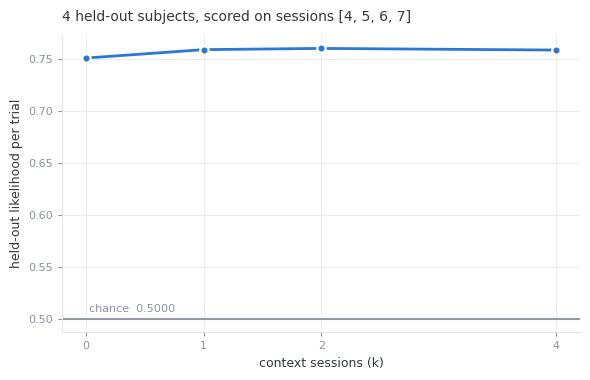

In [17]:
fig = plotting.plot_conditioning_curve(
    scores,
    references={"chance": (0.5, plotting.MUTED)},
    title=f"{N_HELDOUT} held-out subjects, scored on sessions {list(TEST_SESSIONS)}",
)
fig

**Reading this curve.** `k = 0` is what the cohort alone is worth: a subject the model has
never seen a single trial from, predicted from nothing but where mice sit in general. It
already scores about 0.75 per trial against a chance floor of 0.5, and the subject's own
sessions add roughly 0.01 on top before flattening — with the `k = 4` rung landing slightly
*below* `k = 2`.

The shape is right and the size is not. The full experiment in
[`benchmarks/RESULTS.md`](../src/aind_dynamic_foraging_models/hierarchical_bayes/benchmarks/RESULTS.md)
(30 training subjects, 25 sessions x 500 trials) runs 0.695 → 0.714 → 0.721 → 0.722 → 0.724
across `k = 0, 1, 2, 4, 8`: there too, almost everything a subject's own data contributes
arrives in the first session or two and the curve then flattens. What this toy cannot show is
the size of that first step, because four held-out subjects scored on four sessions each puts
the whole spread between rungs inside the noise, and the non-monotonic dip is that noise
being visible.

What the curve is *for* is the scheduling question — how many sessions a new animal needs
before more data stops paying for itself. Answering it needs a cohort big enough for the
rungs to separate; the machinery is the same either way.

For many held-out subjects at once, `heldout.fit_adaptation_batched` conditions them all in
a single sampler run and `heldout.batched_heldout_log_lik` scores the sessions in vmapped
chunks, which on a GPU turns a rung from hours into tens of seconds. The plain loop is
written out above because it is easier to read.

## 8. Save the fit

A cohort fit costs hours; scoring, diagnostics and figures cost minutes. `artifacts.save_fit`
writes posterior draws and sampler diagnostics to netCDF via ArviZ, plus a small JSON with
scalars and provenance (including the commit the fit was produced at), so a new question
never forces a refit.

The diagnostics it returns are the three numbers to look at before believing any of the
above: `max_r_hat` at 1.00, `min_ess_bulk` in the hundreds, and a divergence count that is
small relative to the number of draws. The joint fit here reports a handful of divergences
out of 1000 draws; at this size that is tolerable, and the first thing to try if it grows is
raising NUTS's `target_accept_prob` above its 0.8 default.

In [18]:
from pathlib import Path

from aind_dynamic_foraging_models.hierarchical_bayes.artifacts import load_population, save_fit

output_dir = Path(tempfile.mkdtemp(prefix="hb_demo_fit_"))  # throwaway; point this anywhere
record = save_fit(
    joint_mcmc,
    output_dir,
    name="synthetic_cohort",
    meta={
        "cohort": "synthetic",
        "n_train": N_TRAIN,
        "n_trials": N_TRIALS,
        "seed": SEED,
        "true_population_mean": TRUE_POPULATION_MEAN.tolist(),
    },
)
print(json.dumps(record["diagnostics"], indent=2, default=str))
print("\nwrote:", *sorted(p.name for p in output_dir.iterdir()))

# and read the population back without refitting
reloaded = load_population(record["netcdf"])
print("\nreloaded population_mean:",
      reloaded["population_mean"].mean(axis=0).round(2))

{
  "max_r_hat": 1.0,
  "min_ess_bulk": 130.0,
  "divergences": 7
}

wrote: synthetic_cohort.json synthetic_cohort.nc synthetic_cohort_sample_stats.nc

reloaded population_mean: [ 0.41 -0.55 -0.7   0.18  0.01]


## Where to go next

- **Why the model is built this way** — the non-centred parameterisation, the choice of
  priors, what the two-stage fit approximates and what that approximation costs:
  [`hierarchical_bayes/docs/design-decisions.md`](../src/aind_dynamic_foraging_models/hierarchical_bayes/docs/design-decisions.md)
- **Validation and speed** — parity against the reference Stan implementation, and measured
  timings on CPU and GPU:
  [`hierarchical_bayes/benchmarks/RESULTS.md`](../src/aind_dynamic_foraging_models/hierarchical_bayes/benchmarks/RESULTS.md)
- **The full recovery experiment** — the same comparison as this notebook, at real scale and
  from the command line:
  [`hierarchical_bayes/recovery/estimator_comparison.py`](../src/aind_dynamic_foraging_models/hierarchical_bayes/recovery/estimator_comparison.py)
- **Comparing against Stan** — `model.hattori2019_stan_reference` is a faithful port of the
  AIND reference Stan model, kept so the two can be checked against each other. Note its
  forgetting rate is parameterised as retention, so `mu_p` for that parameter has the
  opposite sign.
- **Per-session MLE fitting**, the non-hierarchical counterpart:
  [`demo_rl_mle_fitting_new_test_time.ipynb`](demo_rl_mle_fitting_new_test_time.ipynb)